In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score


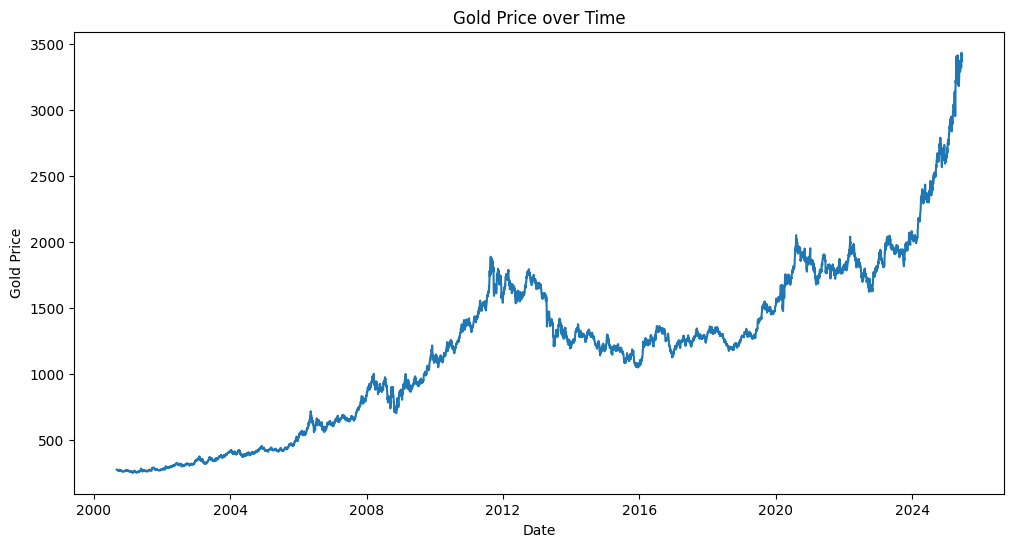

In [2]:
df = pd.read_csv(r"C:\Users\User\dev\training_model\dataset\dataset_v2.csv", parse_dates=['Date'], index_col='Date')

gold = df['Close']
plt.figure(figsize=(12,6))
plt.plot(gold)
plt.title("Gold Price over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.show()

In [3]:
train_size = int(len(gold) * 0.8)
train, test = gold[:train_size], gold[train_size:]

In [4]:
model = ARIMA(train, order=(5,1,0))  
model_fit = model.fit()
print(model_fit.summary())

c:\Users\User\dev\training_model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\User\dev\training_model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\User\dev\training_model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4974
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -19465.339
Date:                Thu, 04 Sep 2025   AIC                          38942.678
Time:                        00:51:37   BIC                          38981.748
Sample:                             0   HQIC                         38956.375
                               - 4974                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0058      0.008     -0.723      0.470      -0.021       0.010
ar.L2         -0.0026      0.009     -0.305      0.761      -0.020       0.014
ar.L3          0.0021      0.009      0.242      0.8

c:\Users\User\dev\training_model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


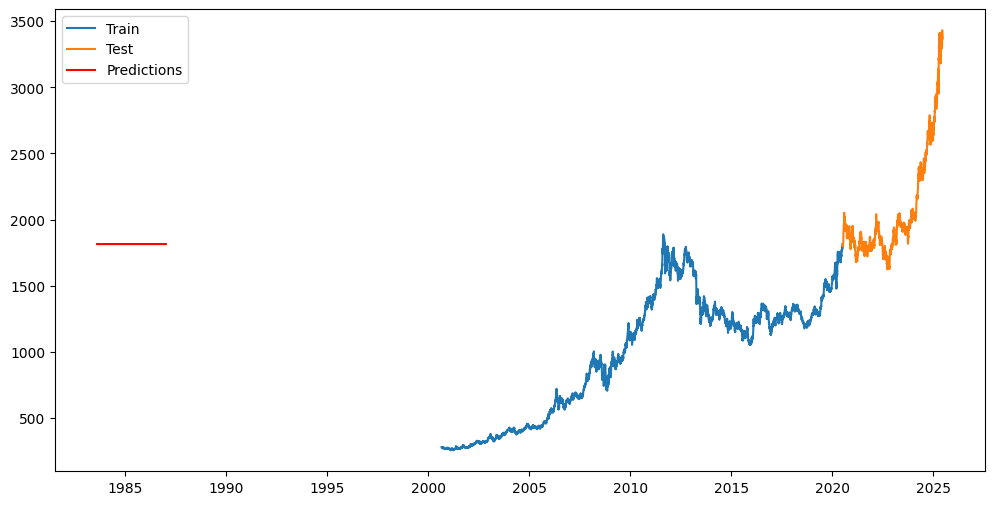

RMSE: 485.46574165315354
R2: -0.4061197269899526


In [5]:
start = len(train)
end = len(train) + len(test) - 1
predictions = model_fit.predict(start=start, end=end, typ='levels')

plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(predictions, color='red', label="Predictions")
plt.legend()
plt.show()


rmse = np.sqrt(mean_squared_error(test, predictions))
r2_score = r2_score(test, predictions)
print(f"RMSE: {rmse}")
print(f"R2: {r2_score}")